# FashionMNIST: Dataset Configuration Ablation

Same model architectures, four different dataset configurations crossing
**positive pairing** (oracle labels vs SimCLR augmentation) with
**negative sampling** (strict oracle vs random non-strict).

| Config | Positives | Negatives | Short name |
|--------|-----------|-----------|------------|
| 1 | Oracle (same-class) | Strict (different-class) | Oracle/Strict |
| 2 | SimCLR augmentation | Strict (different-class) | SimCLR/Strict |
| 3 | Oracle (same-class) | Random (non-strict) | Oracle/Random |
| 4 | SimCLR augmentation | Random (non-strict) | SimCLR/Random |

Models per configuration:
- **CNN**: Deterministic (NonLinearEmbedder)
- **UG**: UncertainGen, identity kernel K=I
- **LLA**: Post-hoc Laplace on CNN
- **UG+LLA**: UG + Laplace (aleatoric + epistemic)

In [16]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, accuracy_score, f1_score

from datasets.image_contrastive import ImageContrastiveDataset
from embedders.nonlinear import NonLinearEmbedder, contrastive_loss, set_seed
from embedders.uncertaingen import UncertainGenEmbedder, train_variance_phase
from embedders.laplace_embedder import LaplaceLastLayerEmbedder
from embedders.base import EmbeddingResult
from features.image import CNNFeatureExtractor
from train import train_contrastive
from evaluation.eval_utils import align_labels_via_hungarian_algorithm

SEED = 26042024
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda


## 1. Load Data

In [17]:
import torchvision, torchvision.transforms as T

def make_dataset(augmentation_mode, augmentation_type="affine", strict_negatives=False):
    return ImageContrastiveDataset(
        dataset_name="fashionmnist", split="train",
        neg_sample_per_pos=10, max_samples=-1,
        data_root="../../data", seed=SEED,
        augmentation_mode=augmentation_mode,
        augmentation_type=augmentation_type,
        strict_negatives=strict_negatives,
    )

# Config 1: Oracle pos + Strict neg  (full oracle)
train_ds_1 = make_dataset(augmentation_mode=False, strict_negatives=True)
# Config 2: SimCLR pos + Strict neg
train_ds_2 = make_dataset(augmentation_mode=True, augmentation_type="simclr", strict_negatives=True)
# Config 3: Oracle pos + Random neg  (non-strict)
train_ds_3 = make_dataset(augmentation_mode=False, strict_negatives=False)
# Config 4: SimCLR pos + Random neg
train_ds_4 = make_dataset(augmentation_mode=True, augmentation_type="simclr", strict_negatives=False)

CONFIGS = {
    "Oracle/Strict":  train_ds_1,
    "SimCLR/Strict":  train_ds_2,
    "Oracle/Random":  train_ds_3,
    "SimCLR/Random":  train_ds_4,
}

# Shared test set
test_ds = torchvision.datasets.FashionMNIST(
    root="../../data", train=False, download=True, transform=T.ToTensor(),
)
test_images = np.array([test_ds[i][0].reshape(-1).numpy() for i in range(len(test_ds))])
test_labels = np.array([test_ds[i][1] for i in range(len(test_ds))])
print(f"Test: {len(test_images)} samples, Feature dim: {train_ds_1.feature_dim}")

 Loading fashionmnist (train) │██████████████████████████████│ 60000/60000 [00:25<00:00]


Dataset loaded: 60000 samples, feature_dim=784, classes=10, pairing=pos=oracle (label), neg=strict (different-class)


 Loading fashionmnist (train) │██████████████████████████████│ 60000/60000 [00:05<00:00]


Dataset loaded: 60000 samples, feature_dim=784, classes=10, pairing=pos=augmentation (simclr), neg=strict (different-class)


 Loading fashionmnist (train) │██████████████████████████████│ 60000/60000 [00:05<00:00]


Dataset loaded: 60000 samples, feature_dim=784, classes=10, pairing=pos=oracle (label), neg=random (non-strict)


 Loading fashionmnist (train) │██████████████████████████████│ 60000/60000 [00:05<00:00]


Dataset loaded: 60000 samples, feature_dim=784, classes=10, pairing=pos=augmentation (simclr), neg=random (non-strict)
Test: 10000 samples, Feature dim: 784


## 2. Hyperparameters

In [18]:
DIM = 64
EPOCHS = 60
UG_P2_EPOCHS = 20
LR = 5e-3
BATCH_SIZE = 128
NUM_WORKERS = 4

LOAD_MODELS = True
SAVE_MODELS = True

# Model directories — configs 1 and 4 reuse models already trained in the main notebook
MODEL_DIRS = {
    "Oracle/Strict":  "../../models/fashionmnist_oracle",         # already trained
    "SimCLR/Strict":  "../../models/fashionmnist_simclr_strict",  # new
    "Oracle/Random":  "../../models/fashionmnist_oracle_random",  # new
    "SimCLR/Random":  "../../models/fashionmnist_simclr",         # already trained
}

## 3. Train Models

`train_pipeline()` trains CNN, UG (identity), LLA-CNN, and UG+LLA for a given dataset.
It reuses saved models from disk when available (e.g. configs 1 and 4 from the main notebook).

In [19]:
MODEL_NAMES = ["CNN", "UG", "LLA", "UG+LLA"]


def train_pipeline(config_name, train_ds, model_dir,
                   load_models=LOAD_MODELS, save_models=SAVE_MODELS):
    """Train CNN, UG (identity), LLA, UG+LLA for one dataset config."""
    os.makedirs(model_dir, exist_ok=True)
    models = {}
    losses = {}

    def _p(name):
        return os.path.join(model_dir, name)

    # ---- CNN ----
    print(f"\n{'='*50}\n[{config_name}] CNN\n{'='*50}")
    cnn_feat = CNNFeatureExtractor(in_channels=1, image_size=28, output_dim=256)
    if load_models and os.path.exists(_p("cnn.model")):
        models["CNN"] = NonLinearEmbedder.load(
            _p("cnn.model"), device=DEVICE, feature_extractor=cnn_feat)
        losses["CNN"] = list(np.load(_p("cnn_loss.npy")))
        print("  Loaded from disk.")
    else:
        set_seed(SEED)
        models["CNN"] = NonLinearEmbedder(
            feature_extractor=cnn_feat, dim=DIM, device=DEVICE, seed=SEED)
        losses["CNN"] = train_contrastive(
            model=models["CNN"], dataset=train_ds, loss_fn=contrastive_loss,
            lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
            num_workers=NUM_WORKERS, verbose=True,
        )
        if save_models:
            models["CNN"].save(_p("cnn.model"))
            np.save(_p("cnn_loss.npy"), np.array(losses["CNN"]))

    # ---- UG (identity) ----
    print(f"\n{'='*50}\n[{config_name}] UG (identity)\n{'='*50}")
    ug_feat = CNNFeatureExtractor(in_channels=1, image_size=28, output_dim=256)
    if load_models and os.path.exists(_p("ug_id.model")):
        models["UG"] = UncertainGenEmbedder.load(
            _p("ug_id.model"), device=DEVICE, feature_extractor=ug_feat)
        losses["UG P2"] = list(np.load(_p("ug_id_loss_p2.npy")))
        print("  Loaded from disk.")
    else:
        set_seed(SEED)
        models["UG"] = UncertainGenEmbedder(
            feature_extractor=ug_feat, dim=DIM, k_form="identity",
            device=DEVICE, seed=SEED,
        )
        models["UG"].copy_mean_from(models["CNN"])
        losses["UG P2"] = train_variance_phase(
            model=models["UG"], dataset=train_ds,
            lr=LR, epochs=UG_P2_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
            num_workers=NUM_WORKERS, verbose=True,
        )
        if save_models:
            models["UG"].save(_p("ug_id.model"))
            np.save(_p("ug_id_loss_p2.npy"), np.array(losses["UG P2"]))

    # ---- LLA (post-hoc on CNN) ----
    print(f"\n{'='*50}\n[{config_name}] LLA\n{'='*50}")
    models["LLA"] = LaplaceLastLayerEmbedder(models["CNN"], prior_precision=1.0)
    models["LLA"].fit(train_ds, contrastive_loss, batch_size=64, device=DEVICE)
    models["LLA"].optimize_prior()

    # ---- UG+LLA (post-hoc on UG mean network) ----
    print(f"\n{'='*50}\n[{config_name}] UG+LLA\n{'='*50}")
    models["UG"].linear2 = models["UG"].mean_linear2
    _lla_ug = LaplaceLastLayerEmbedder(models["UG"], prior_precision=1.0)
    _lla_ug.fit(train_ds, contrastive_loss, batch_size=64, device=DEVICE)
    _lla_ug.optimize_prior()
    models["_lla_ug"] = _lla_ug

    print(f"\n[{config_name}] All models ready.")
    return models, losses


def embed_pipeline(models, test_images):
    """Embed test images with all model variants."""
    embs = {}
    for name in MODEL_NAMES:
        if name == "UG+LLA":
            continue
        embs[name] = models[name].embed(test_images)

    # UG+LLA: aleatoric (UG) + epistemic (LLA)
    lla_ug_emb = models["_lla_ug"].embed(test_images)
    embs["UG+LLA"] = EmbeddingResult(
        mean=embs["UG"].mean,
        variance=embs["UG"].variance + lla_ug_emb.variance,
    )
    return embs

In [20]:
all_models = {}
all_losses = {}

for config_name, train_ds in CONFIGS.items():
    model_dir = MODEL_DIRS[config_name]
    models, losses = train_pipeline(config_name, train_ds, model_dir)
    all_models[config_name] = models
    all_losses[config_name] = losses


[Oracle/Strict] CNN


 Training │██████████████████████████████│ 60/60 [22:01<00:00, loss=0.149592]



[Oracle/Strict] UG (identity)


 Phase 2 (variance) │██████████████████████████████│ 20/20 [02:47<00:00, loss=0.157800]



[Oracle/Strict] LLA


...


[SimCLR/Random] LLA


 LLA fit │██████████████████████████████│ 938/938 [00:54<00:00]


LLA fitted on 1320000 samples (B: GGN).
  S_A range: [1.00e-06, 1.06e+00]
  S_B range: [1.82e-01, 3.99e+00]
  prior converged at step 17: tau=15.7421, gamma=5251.3/32832
  optimized prior_precision = 15.7421

[SimCLR/Random] UG+LLA


 LLA fit │██████████████████████████████│ 938/938 [00:55<00:00]

LLA fitted on 1320000 samples (B: GGN).
  S_A range: [1.00e-06, 1.06e+00]
  S_B range: [1.82e-01, 3.97e+00]
  prior converged at step 17: tau=15.7424, gamma=5251.4/32832
  optimized prior_precision = 15.7423

[SimCLR/Random] All models ready.


## 4. Loss Curves

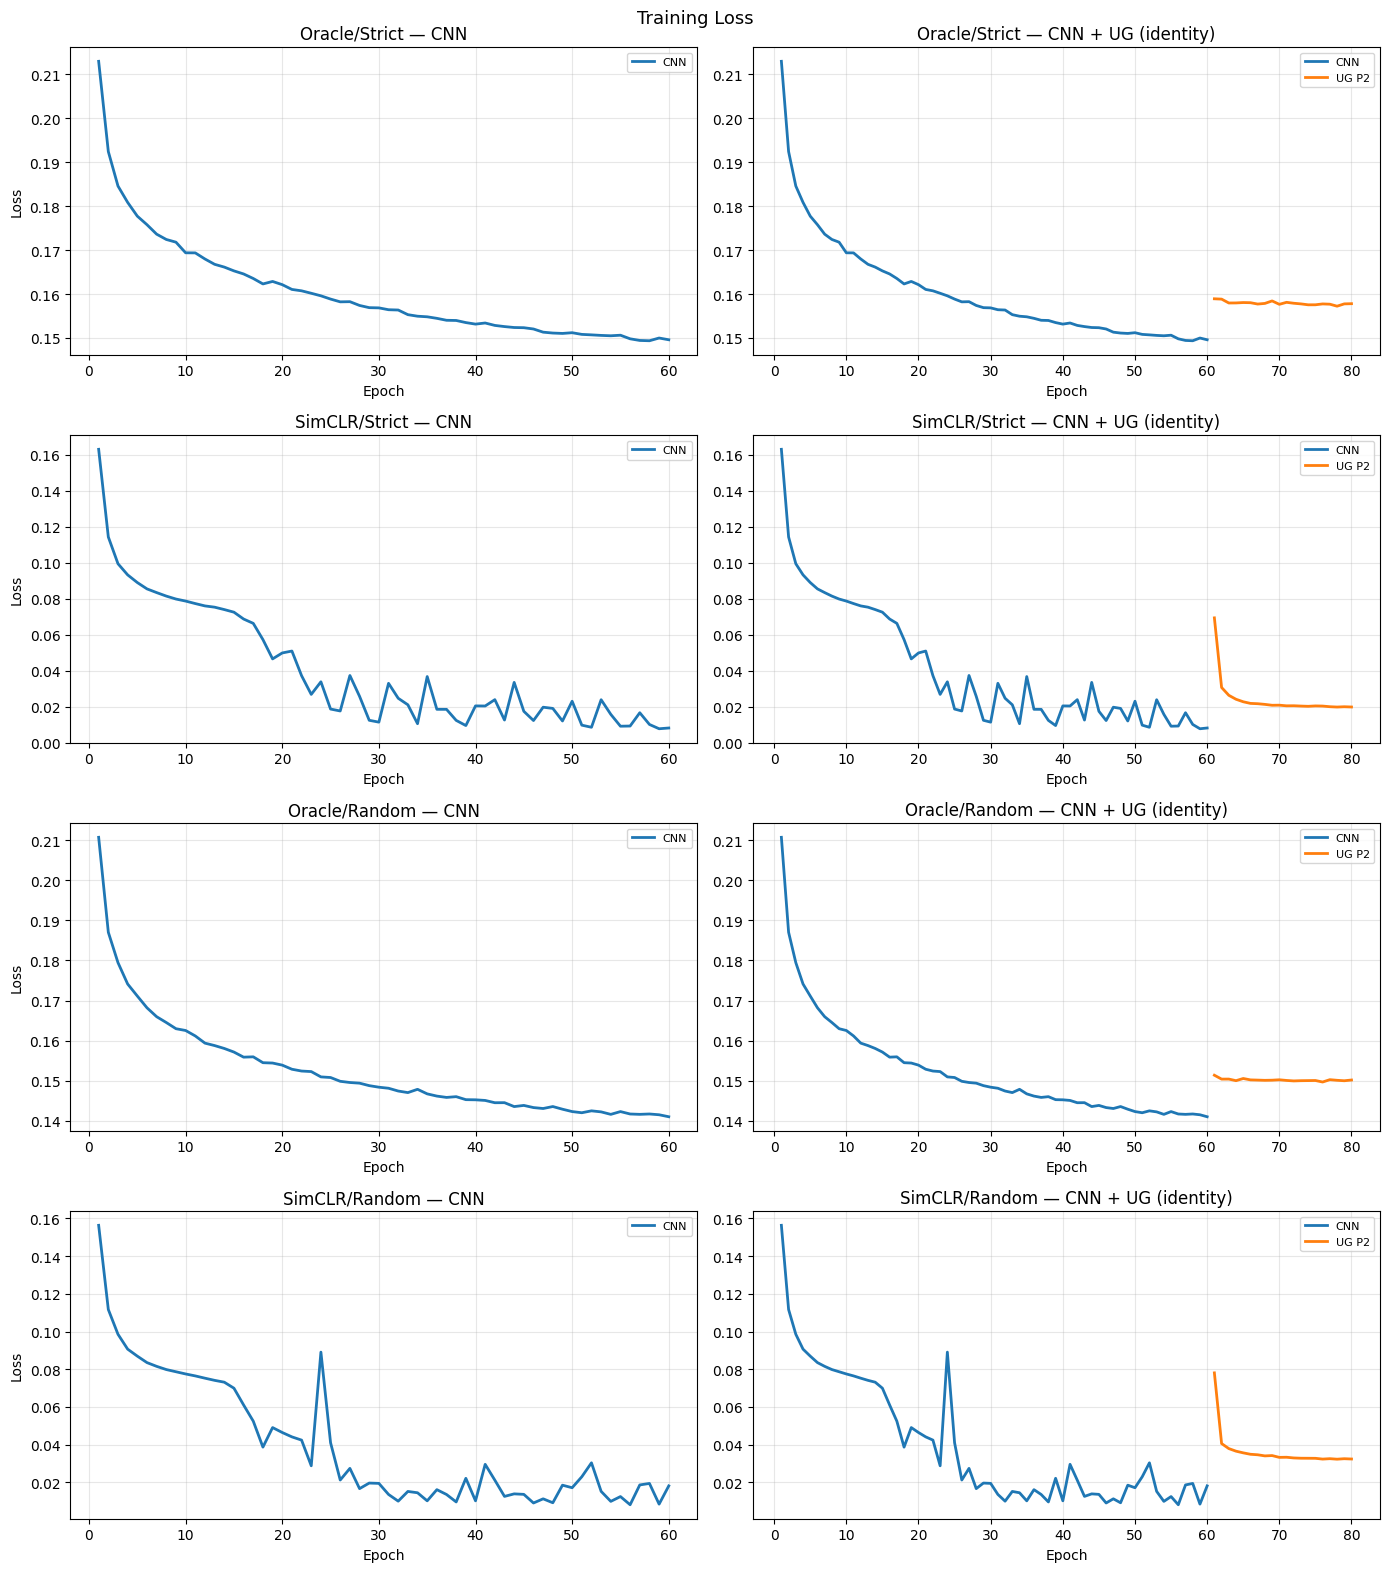

In [21]:
CONFIG_NAMES = list(CONFIGS.keys())

fig, axes = plt.subplots(len(CONFIG_NAMES), 2, figsize=(14, 4 * len(CONFIG_NAMES)))

for row, config_name in enumerate(CONFIG_NAMES):
    losses = all_losses[config_name]
    n_p1 = len(losses["CNN"])

    # CNN loss
    ax = axes[row, 0]
    ax.plot(range(1, n_p1 + 1), losses["CNN"], linewidth=2, label="CNN")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(f"{config_name} — CNN")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # CNN + UG Phase 2
    ax = axes[row, 1]
    ax.plot(range(1, n_p1 + 1), losses["CNN"], linewidth=2, label="CNN")
    if "UG P2" in losses:
        ug_vals = losses["UG P2"]
        ax.plot(range(n_p1 + 1, n_p1 + len(ug_vals) + 1), ug_vals,
                linewidth=2, label="UG P2")
    ax.set_xlabel("Epoch")
    ax.set_title(f"{config_name} — CNN + UG (identity)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Training Loss", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Embed Test Set

In [22]:
all_embs = {}
for config_name in CONFIG_NAMES:
    all_embs[config_name] = embed_pipeline(all_models[config_name], test_images)

for config_name in CONFIG_NAMES:
    print(f"\n{config_name}:")
    for name, emb in all_embs[config_name].items():
        shape_str = f"mean {emb.mean.shape}"
        if emb.is_probabilistic:
            shape_str += f", var {emb.variance.shape}"
        print(f"  {name:10s} {shape_str}")


Oracle/Strict:
  CNN        mean (10000, 64)
  UG         mean (10000, 64), var (10000, 64)
  LLA        mean (10000, 64), var (10000, 64)
  UG+LLA     mean (10000, 64), var (10000, 64)

SimCLR/Strict:
  CNN        mean (10000, 64)
  UG         mean (10000, 64), var (10000, 64)
  LLA        mean (10000, 64), var (10000, 64)
  UG+LLA     mean (10000, 64), var (10000, 64)

Oracle/Random:
  CNN        mean (10000, 64)
  UG         mean (10000, 64), var (10000, 64)
  LLA        mean (10000, 64), var (10000, 64)
  UG+LLA     mean (10000, 64), var (10000, 64)

SimCLR/Random:
  CNN        mean (10000, 64)
  UG         mean (10000, 64), var (10000, 64)
  LLA        mean (10000, 64), var (10000, 64)
  UG+LLA     mean (10000, 64), var (10000, 64)


## 6. Cluster & Evaluate

K-Means (k=10) on all four dataset configurations.

In [23]:
def score_predictions(pred, true_labels, name):
    mask = pred != -1
    n_assigned = mask.sum()
    n_total = len(true_labels)
    coverage = n_assigned / n_total

    if n_assigned == 0:
        print(f"{name:50s}  Acc=0.0000  NMI=0.0000  ARI=0.0000  F1=0.0000  "
              f"k=0  cov={coverage:.1%}")
        return {"name": name, "acc": 0, "nmi": 0, "ari": 0, "f1": 0,
                "k": 0, "coverage": 0.0}

    label_map = align_labels_via_hungarian_algorithm(true_labels[mask], pred[mask])
    full_aligned = np.full(n_total, -1)
    full_aligned[mask] = np.array([label_map.get(p, p) for p in pred[mask]])

    acc = accuracy_score(true_labels, full_aligned)
    nmi = normalized_mutual_info_score(true_labels, pred)
    ari = adjusted_rand_score(true_labels, pred)
    f1 = f1_score(true_labels, full_aligned, average="macro", zero_division=0)
    n_clusters = len(set(pred[mask]))

    print(f"{name:50s}  Acc={acc:.4f}  NMI={nmi:.4f}  ARI={ari:.4f}  F1={f1:.4f}  "
          f"k={n_clusters}  cov={coverage:.1%}")
    return {"name": name, "acc": acc, "nmi": nmi, "ari": ari, "f1": f1,
            "k": n_clusters, "coverage": coverage}


all_results = []

for config_name in CONFIG_NAMES:
    embs = all_embs[config_name]
    print(f"\n{'='*65}")
    print(f"  {config_name}")
    print(f"{'='*65}")

    print("\n--- K-Means (k=10) ---")
    for mname in MODEL_NAMES:
        km = KMeans(n_clusters=10, random_state=SEED, n_init=10)
        pred = km.fit_predict(embs[mname].mean)
        all_results.append(
            score_predictions(pred, test_labels, f"{config_name} / {mname}"))


  Oracle/Strict

--- K-Means (k=10) ---
Oracle/Strict / CNN                                 Acc=0.9191  NMI=0.8562  ARI=0.8376  F1=0.9196  k=10  cov=100.0%
Oracle/Strict / UG                                  Acc=0.9191  NMI=0.8562  ARI=0.8376  F1=0.9196  k=10  cov=100.0%
Oracle/Strict / LLA                                 Acc=0.9191  NMI=0.8562  ARI=0.8376  F1=0.9196  k=10  cov=100.0%
Oracle/Strict / UG+LLA                              Acc=0.9191  NMI=0.8562  ARI=0.8376  F1=0.9196  k=10  cov=100.0%

  SimCLR/Strict

--- K-Means (k=10) ---
SimCLR/Strict / CNN                                 Acc=0.5021  NMI=0.5449  ARI=0.3841  F1=0.4719  k=10  cov=100.0%
SimCLR/Strict / UG                                  Acc=0.5021  NMI=0.5449  ARI=0.3841  F1=0.4719  k=10  cov=100.0%
SimCLR/Strict / LLA                                 Acc=0.5021  NMI=0.5449  ARI=0.3841  F1=0.4719  k=10  cov=100.0%
SimCLR/Strict / UG+LLA                              Acc=0.5021  NMI=0.5449  ARI=0.3841  F1=0.4719  k=10  c

## 7. t-SNE Visualization

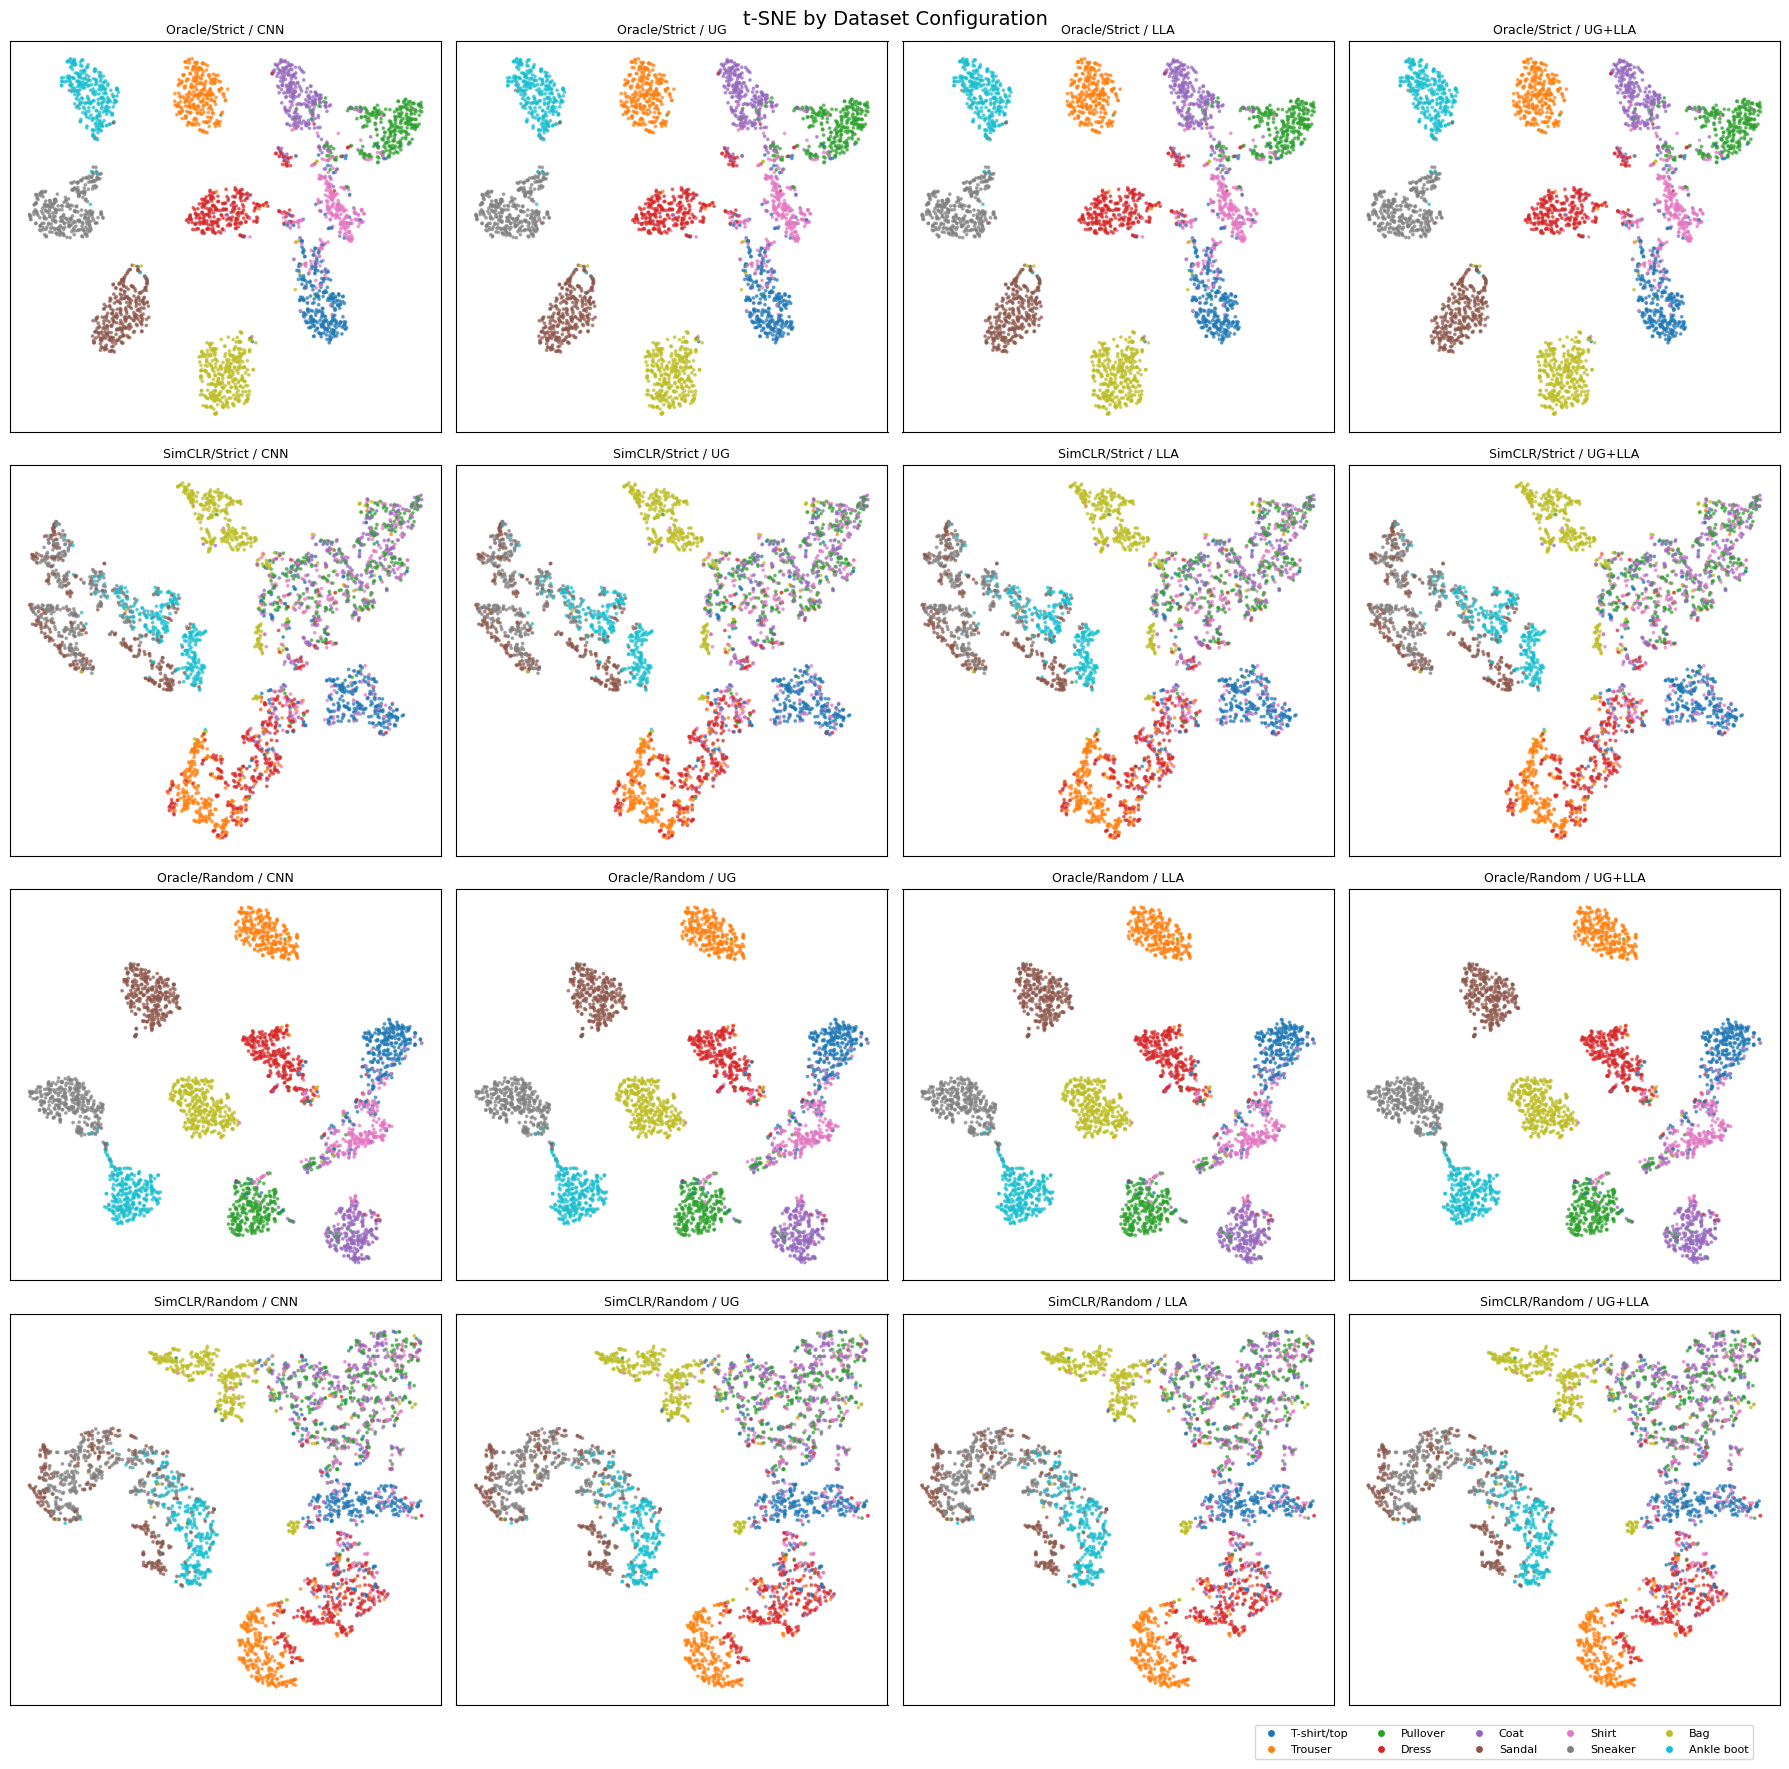

In [24]:
N_VIS = 3000
rng = np.random.RandomState(SEED)
vis_idx = rng.choice(len(test_labels), N_VIS, replace=False)
vis_labels = test_labels[vis_idx]

FMNIST_CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                  "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
cmap = plt.cm.tab10

# 4 configs x 4 models = 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(18, 18))

for row, config_name in enumerate(CONFIG_NAMES):
    embs = all_embs[config_name]
    for col, mname in enumerate(MODEL_NAMES):
        ax = axes[row, col]
        tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
        coords = tsne.fit_transform(embs[mname].mean[vis_idx])
        ax.scatter(coords[:, 0], coords[:, 1], c=vis_labels,
                   cmap="tab10", s=3, alpha=0.6)
        ax.set_title(f"{config_name} / {mname}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap(i), markersize=6, label=FMNIST_CLASSES[i])
           for i in range(10)]
fig.legend(handles=handles, loc="lower right", ncol=5, fontsize=8,
           frameon=True, bbox_to_anchor=(0.98, 0.005))

plt.suptitle("t-SNE by Dataset Configuration", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 8. Uncertainty Analysis

Compare per-sample uncertainty distributions across dataset configurations
for all probabilistic models (UG, LLA, UG+LLA).

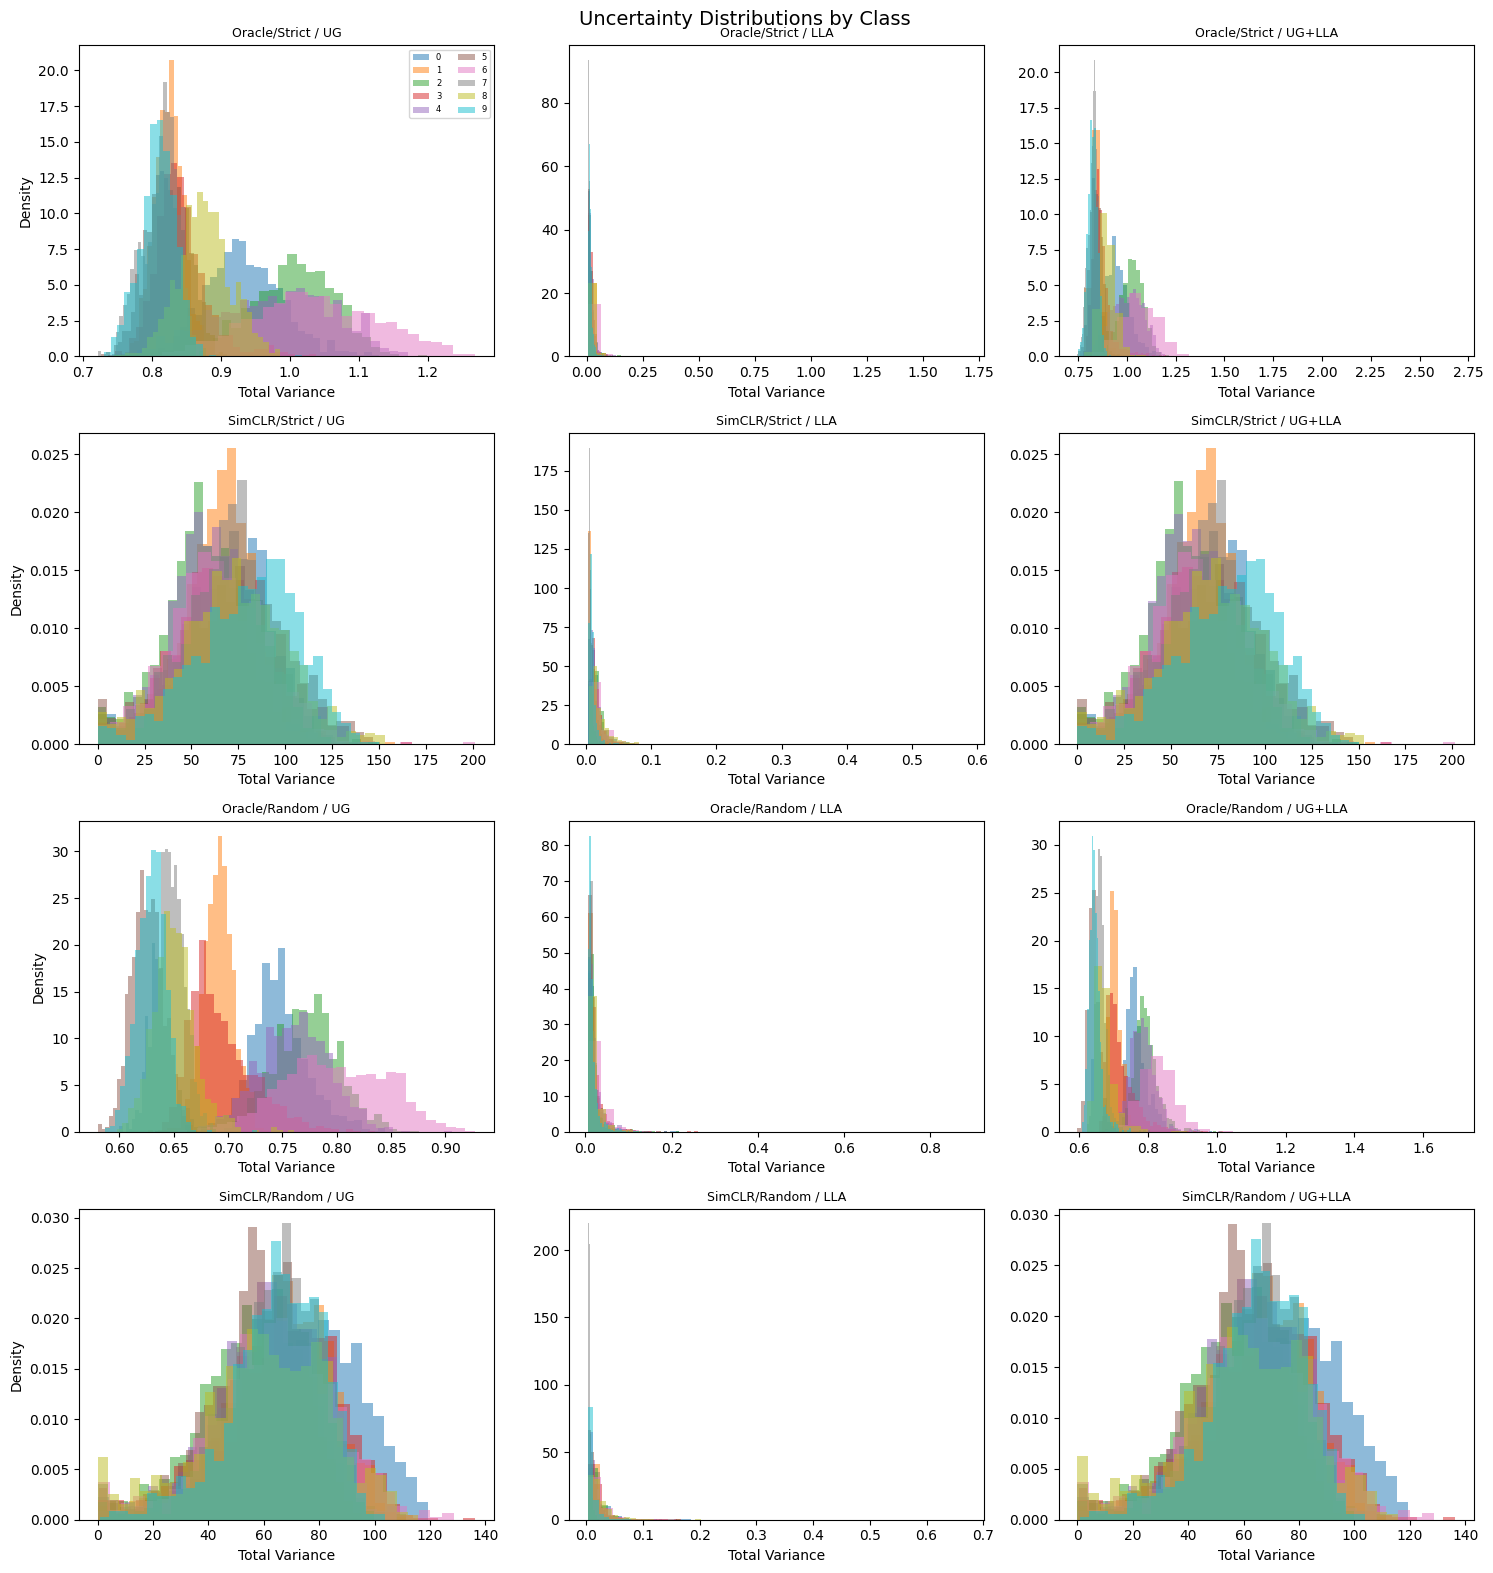

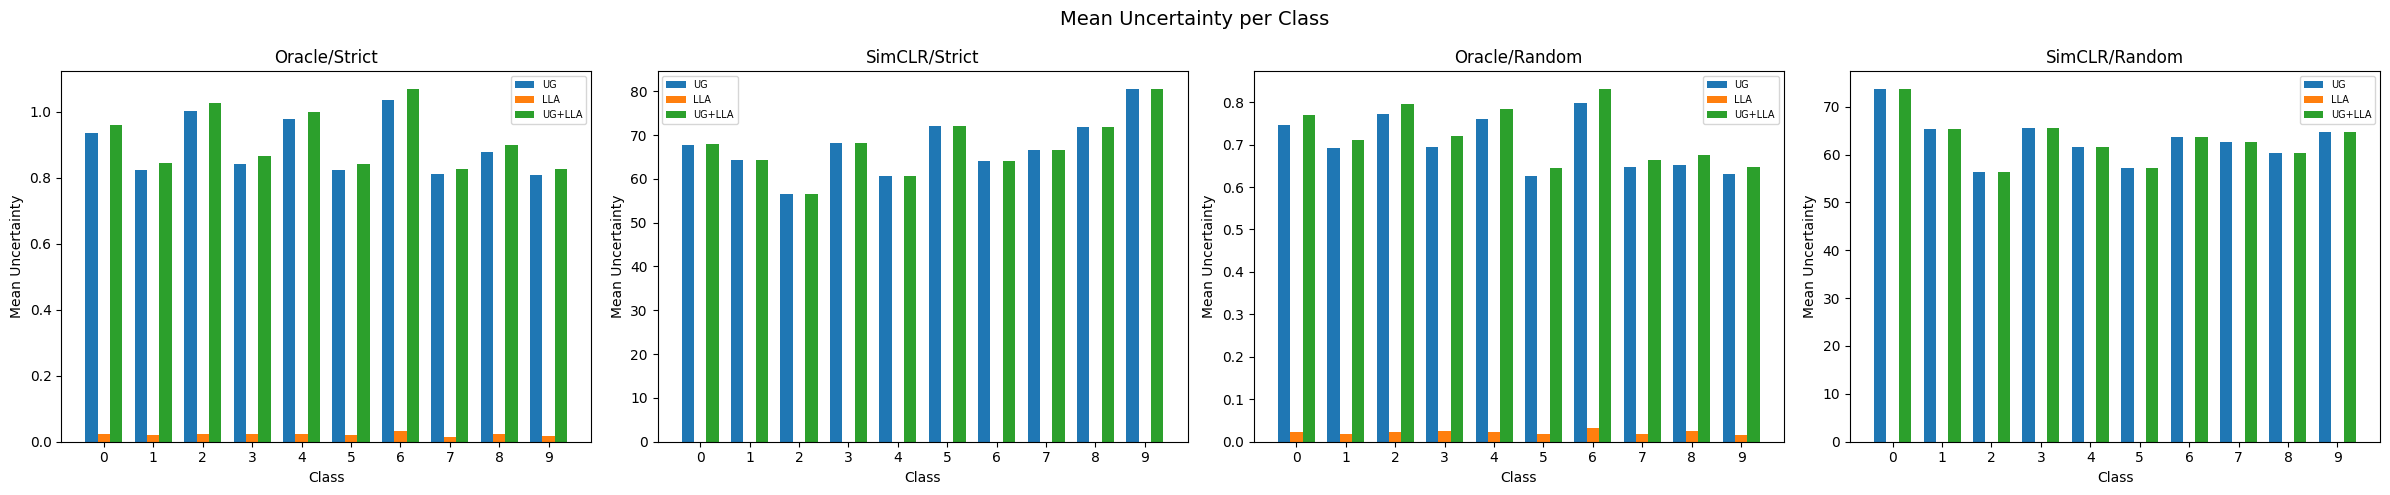

In [25]:
PROB_NAMES = ["UG", "LLA", "UG+LLA"]

# Compute uncertainties
unc = {}
for config_name in CONFIG_NAMES:
    embs = all_embs[config_name]
    for mname in PROB_NAMES:
        unc[(config_name, mname)] = embs[mname].variance.sum(axis=1)

# Histograms: 4 configs x 3 prob models = 4x3 grid
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for row, config_name in enumerate(CONFIG_NAMES):
    for col, mname in enumerate(PROB_NAMES):
        ax = axes[row, col]
        u = unc[(config_name, mname)]
        for cls in range(10):
            mask = test_labels == cls
            ax.hist(u[mask], bins=30, alpha=0.5, label=str(cls), density=True)
        ax.set_title(f"{config_name} / {mname}", fontsize=9)
        ax.set_xlabel("Total Variance")
        if col == 0:
            ax.set_ylabel("Density")
        if row == 0 and col == 0:
            ax.legend(ncol=2, fontsize=6)
plt.suptitle("Uncertainty Distributions by Class", fontsize=14)
plt.tight_layout()
plt.show()

# Bar chart: mean uncertainty per class, one subplot per config
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
x = np.arange(10)
width = 0.25
for ax_idx, config_name in enumerate(CONFIG_NAMES):
    ax = axes[ax_idx]
    for i, mname in enumerate(PROB_NAMES):
        u = unc[(config_name, mname)]
        means = [u[test_labels == d].mean() for d in range(10)]
        ax.bar(x + i * width, means, width, label=mname)
    ax.set_xlabel("Class")
    ax.set_ylabel("Mean Uncertainty")
    ax.set_title(f"{config_name}")
    ax.set_xticks(x + width)
    ax.set_xticklabels(range(10))
    ax.legend(fontsize=7)
plt.suptitle("Mean Uncertainty per Class", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# t-SNE colored by class and uncertainty for each config x prob model
n_rows = len(CONFIG_NAMES) * len(PROB_NAMES)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))

FMNIST_CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                  "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
cmap = plt.cm.tab10

plot_row = 0
for config_name in CONFIG_NAMES:
    embs = all_embs[config_name]
    for mname in PROB_NAMES:
        u = unc[(config_name, mname)]
        tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
        coords = tsne.fit_transform(embs[mname].mean[vis_idx])
        u_vis = u[vis_idx]

        ax_cls = axes[plot_row, 0]
        ax_cls.scatter(coords[:, 0], coords[:, 1], c=vis_labels,
                       cmap="tab10", s=3, alpha=0.6)
        ax_cls.set_title(f"{config_name} / {mname}: Class", fontsize=8)
        ax_cls.set_xticks([]); ax_cls.set_yticks([])

        ax_unc = axes[plot_row, 1]
        sc = ax_unc.scatter(coords[:, 0], coords[:, 1], c=u_vis,
                            cmap="hot", s=3, alpha=0.6)
        ax_unc.set_title(f"{config_name} / {mname}: Uncertainty", fontsize=8)
        ax_unc.set_xticks([]); ax_unc.set_yticks([])

        plot_row += 1

handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap(i), markersize=6, label=FMNIST_CLASSES[i])
           for i in range(10)]
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=8,
           frameon=True, bbox_to_anchor=(0.5, 0.0))

plt.suptitle("Embedding Space: Class Labels vs Uncertainty", fontsize=14)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

## 9. Uncertainty Filtering

Remove the top X% most uncertain samples, then K-Means on the rest.
Compare across all four dataset configurations.

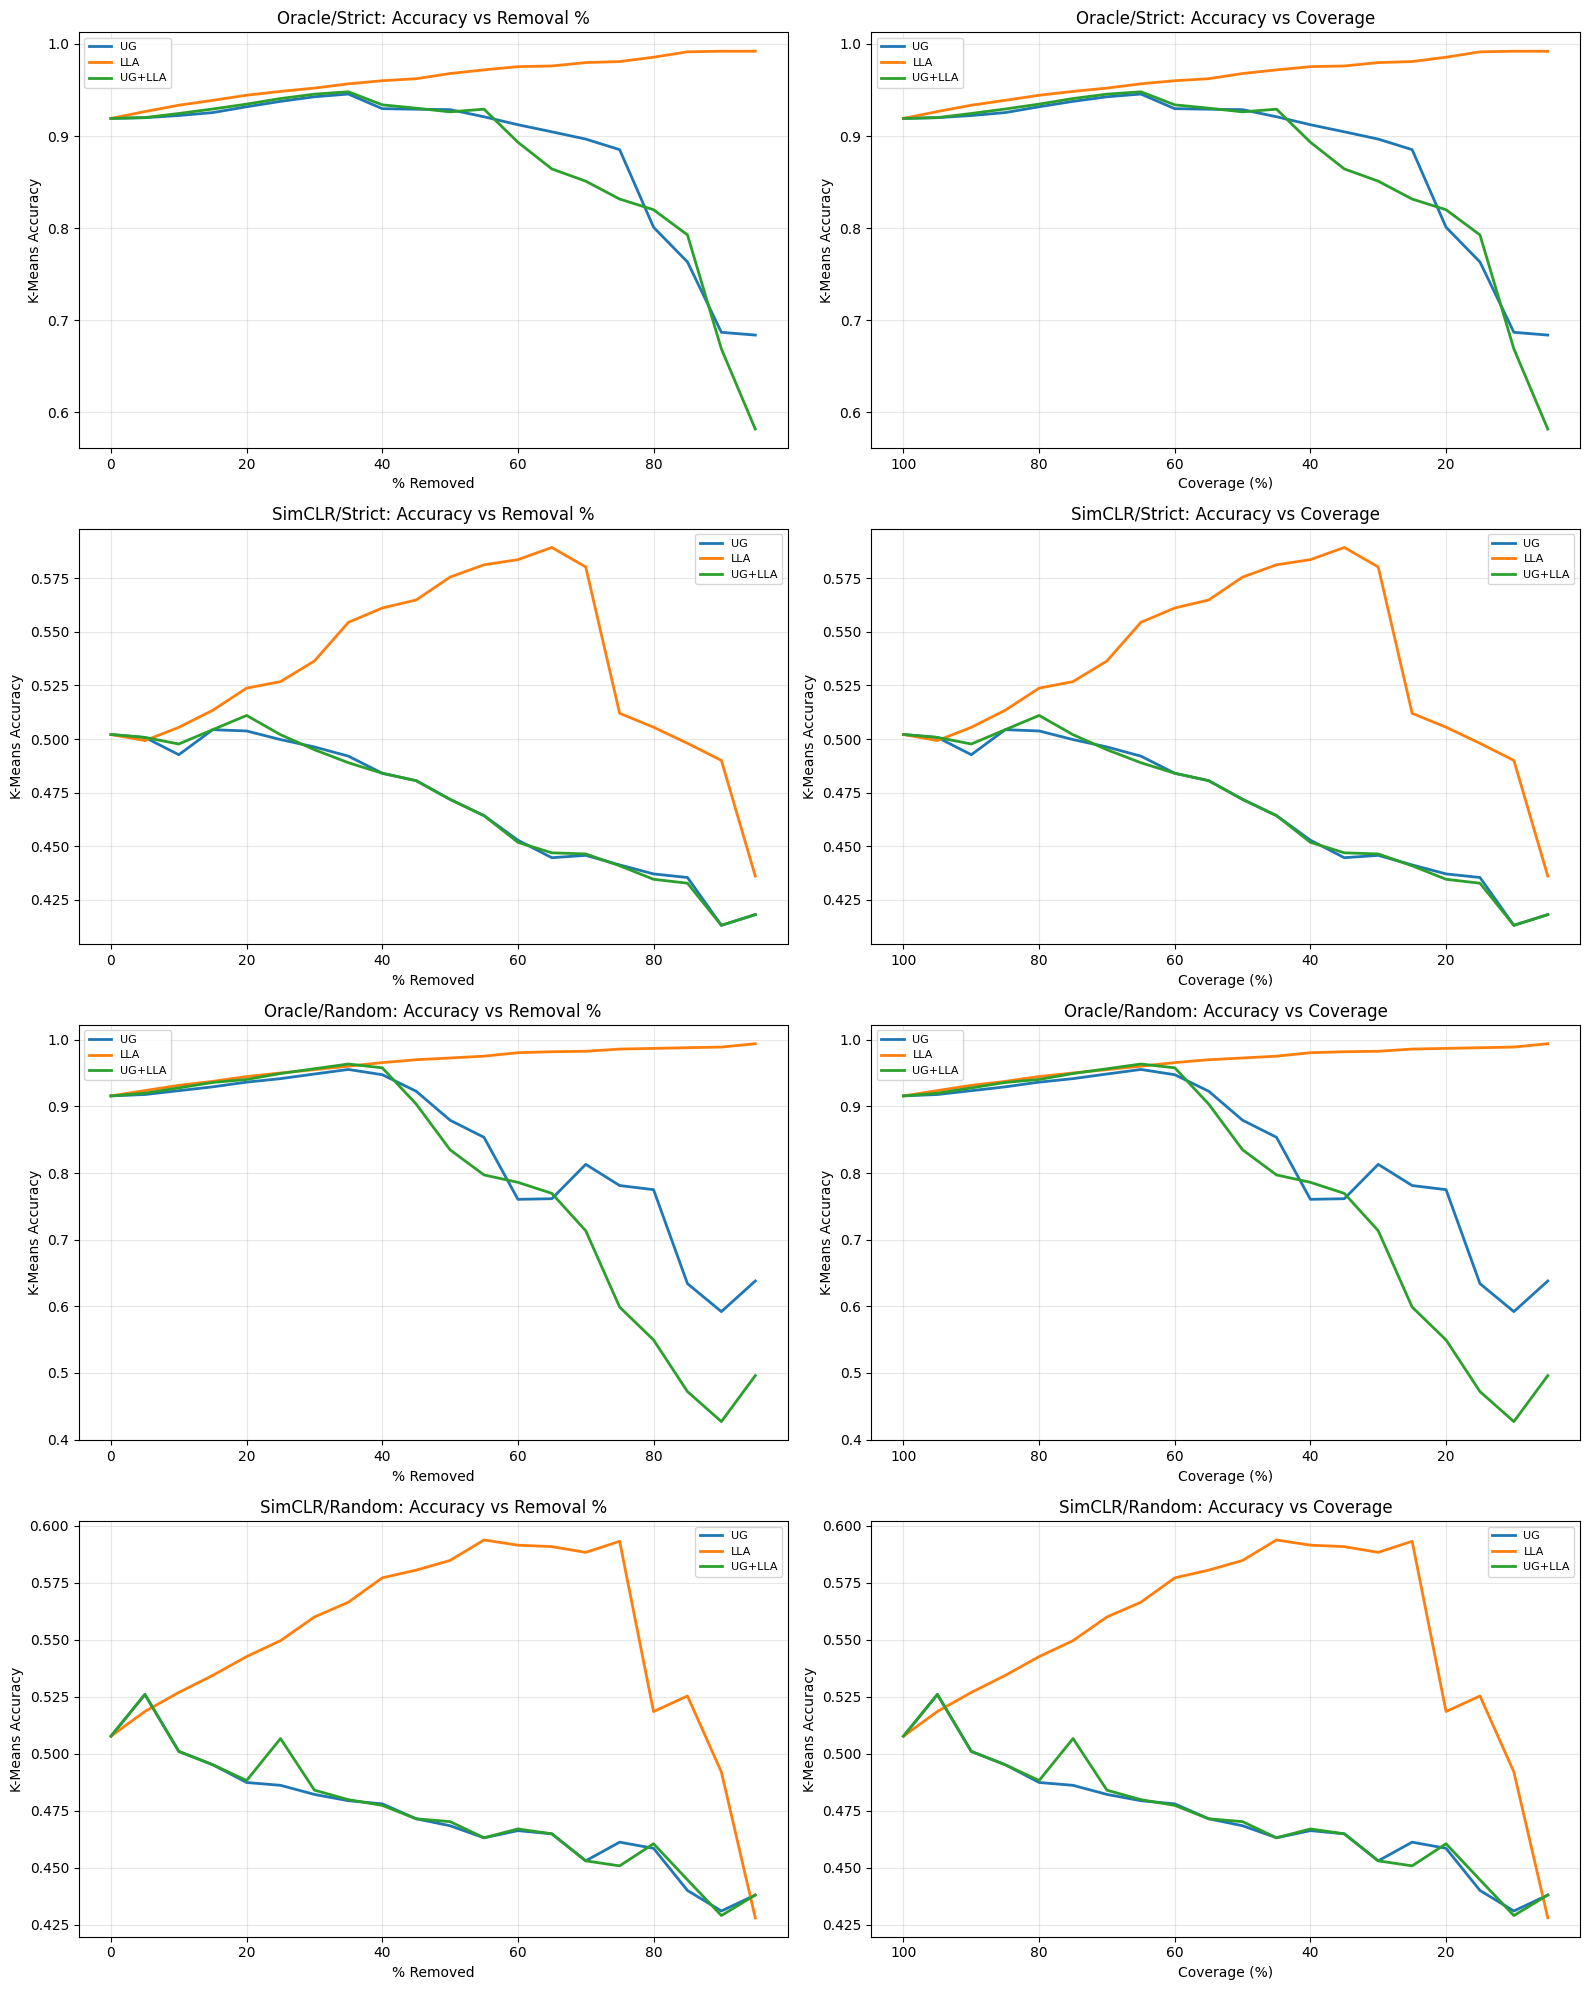


Oracle/Strict:
  UG          best acc=0.9455 at 35% removed (cov=65.0%)
  LLA         best acc=0.9920 at 90% removed (cov=10.0%)
  UG+LLA      best acc=0.9480 at 35% removed (cov=65.0%)

SimCLR/Strict:
  UG          best acc=0.5044 at 15% removed (cov=85.0%)
  LLA         best acc=0.5894 at 65% removed (cov=35.0%)
  UG+LLA      best acc=0.5110 at 20% removed (cov=80.0%)

Oracle/Random:
  UG          best acc=0.9554 at 35% removed (cov=65.0%)
  LLA         best acc=0.9940 at 95% removed (cov=5.0%)
  UG+LLA      best acc=0.9635 at 35% removed (cov=65.0%)

SimCLR/Random:
  UG          best acc=0.5260 at 5% removed (cov=95.0%)
  LLA         best acc=0.5938 at 55% removed (cov=45.0%)
  UG+LLA      best acc=0.5260 at 5% removed (cov=95.0%)


In [27]:
filter_pcts = np.arange(0, 105, 5)

filter_results = {}
for config_name in CONFIG_NAMES:
    embs = all_embs[config_name]
    for mname in PROB_NAMES:
        key = (config_name, mname)
        u = unc[key]
        accs, covs = [], []
        for pct in filter_pcts:
            if pct >= 100:
                accs.append(np.nan)
                covs.append(0.0)
                continue
            keep = np.ones(len(u), dtype=bool) if pct == 0 else (u <= np.percentile(u, 100 - pct))
            n_keep = keep.sum()
            if n_keep < 10:
                accs.append(np.nan)
                covs.append(n_keep / len(u))
                continue
            km = KMeans(n_clusters=10, random_state=SEED, n_init=10)
            pred = km.fit_predict(embs[mname].mean[keep])
            kept_labels = test_labels[keep]
            label_map = align_labels_via_hungarian_algorithm(kept_labels, pred)
            aligned = np.array([label_map.get(p, p) for p in pred])
            accs.append(accuracy_score(kept_labels, aligned))
            covs.append(n_keep / len(u))
        filter_results[key] = {"acc": accs, "cov": covs}

# 4x2 grid: one row per config, columns = Removal% and Coverage
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for row, config_name in enumerate(CONFIG_NAMES):
    colors = [f"C{i}" for i in range(len(PROB_NAMES))]

    # Accuracy vs Removal %
    ax = axes[row, 0]
    for i, mname in enumerate(PROB_NAMES):
        res = filter_results[(config_name, mname)]
        ax.plot(filter_pcts, res["acc"], color=colors[i], linewidth=2, label=mname)
    ax.set_xlabel("% Removed")
    ax.set_ylabel("K-Means Accuracy")
    ax.set_title(f"{config_name}: Accuracy vs Removal %")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Accuracy vs Coverage
    ax = axes[row, 1]
    for i, mname in enumerate(PROB_NAMES):
        res = filter_results[(config_name, mname)]
        ax.plot([c * 100 for c in res["cov"]], res["acc"], color=colors[i], linewidth=2, label=mname)
    ax.set_xlabel("Coverage (%)")
    ax.set_ylabel("K-Means Accuracy")
    ax.set_title(f"{config_name}: Accuracy vs Coverage")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

# Best accuracy per model per config
for config_name in CONFIG_NAMES:
    print(f"\n{config_name}:")
    for mname in PROB_NAMES:
        res = filter_results[(config_name, mname)]
        valid = [(a, p, c) for a, p, c in zip(res["acc"], filter_pcts, res["cov"]) if not np.isnan(a)]
        if valid:
            best_a, best_p, best_c = max(valid, key=lambda x: x[0])
            print(f"  {mname:10s}  best acc={best_a:.4f} "
                  f"at {best_p}% removed (cov={best_c:.1%})")